# Project

# 1 Introduction and documentation

In this project I will be using a customer segment dataset from Kaggle. This dataset includes data about customer demographics such as age, gender, and income, as well as behaviours, for example purchase frequency, prefered category and spending score.

The goal of this project is to find specific customer segments within the customer base in this dataset, and analyse sales patterns within these different customer segments. Using Google Gemini's API, I also aim to find which targeted marketing strategies are most suitable for each customer segment based on the findings from this dataset.

# Documentation:

Before running this notebook, you need to install the required libraries that I have used in this project:
pandas
numpy
matplotlib
seaborn
scikit-learn
google-genai
python-dotenv


How to run this project:
1. Download this file
2. Make sure to also download the "data" folder in the project folder which contains all the data files needed
3. This project uses Gemini API. Create a ".env" file in the same folder with your Gemini API key.
(in the beginning I have also used Kaggle API but you can skip this as I exported the dataset to the "data" folder)
4. Open the notebook in Jupyter and run with the Kernel "Python conda env:base"

You can also run this project without a Gemini API key:
In this case, you can run the full notebook using the pre-analyzed data. Skip the API cells and instead run the 
commented-out cells marked "for peer reviewers" in the end of the Gemini API section.

The structure of the repository is as follows:
- project file
- data folder with exported raw data as well as exported analysed data and findings

The dataset I used for this project can also be found here:
https://www.kaggle.com/datasets/fahmidachowdhury/customer-segmentation-data-for-marketing-analysis?resource=download

# Use of AI in this project
I have used Claude to help me with this project, especially in the data analysis section where I wasn't sure how to analyse my data in the most effective way. I chose my topic and my dataset by brainstorming myself, and ended up going with a marketing related topic as this is something that interests me (my major is marketing). I found the dataset I chose by searching on Kaggle. For most of the steps in this project, I have taken inspiration from the exercises and assignments in this course, and used similar code as I've used before. For the data analysis section, I brainstormed with Claude about what methods would make the most sense for my project, and as the K-means clustering was a new method for myself, I did this part with both googling K-means clustering and looking up how to use it (e.g from Scikit-learn), and also using Claude for help in writing some of the code and troubleshooting when something didn't work. Same goes for the sales analysis as well. For the Gemini API part I once again went back to the exercise where we had used it before, but also used Claude to help me along the way. So, Claude has been used in several sections of this project, but the final code has been written by myself. Also, when it comes to all text and comments, those are fully written by me. At times I have asked clarifying questions from Claude to explain things, but not for writing the final text. The visuals are also made by me.

# 2 Pipeline Visual
Below is a figure showcasing the pipeline of the project. I created this visual using Canva.

![Data Pipeline](data/projectpipeline.png)

# 3 Data Extraction
In this section I downloaded the dataset I am using in this project through Kaggle API. I then exported it to the data folder in this project folder, and proceeded to import the dataset to this jupyter notebook as a dataset. The reviewers can therefore skip this Kaggle API step and go directly to importing the dataset. 

In [1]:
from dotenv import load_dotenv
import os

# reading API key from .env file
load_dotenv()

api_key = os.environ.get("KAGGLE_KEY")

if api_key:
    print(f"Key loaded: {api_key[:3]}...")
else:
    print("ERROR: KAGGLE_KEY not found. Check your .env file.")

Key loaded: KGA...


In [2]:
pip install kagglehub

  Using cached kagglehub-1.0.1-py3-none-any.whl.metadata (40 kB)
  Using cached kagglesdk-0.1.23-py3-none-any.whl.metadata (13 kB)
Using cached kagglehub-1.0.1-py3-none-any.whl (70 kB)
Using cached kagglesdk-0.1.23-py3-none-any.whl (217 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kagglehub]━ 1/2 [kagglehub]
Note: you may need to restart the kernel to use updated packages.


In [5]:
import kagglehub

# Downloading dataset and exporting to repository
path = kagglehub.dataset_download("fahmidachowdhury/customer-segmentation-data-for-marketing-analysis", output_dir='./data')

print("Path to dataset files:", path)

100%|███████████████████████████████████████| 16.4k/16.4k [00:00<00:00, 490kB/s]

Extracting files...
Path to dataset files: ./data


In [1]:
import pandas as pd
import numpy as np

#importing dataset as a dataframe

df_marketing = pd.read_csv("data/customer_segmentation_data.csv")
print("Shape:", df_marketing.shape)
print()
print("Marketing Segmentation Data")
df_marketing.head()

Shape: (1000, 9)

Marketing Segmentation Data


,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,1,38,Female,99342,90,3,24,Groceries,113.53
1,2,21,Female,78852,60,2,42,Sports,41.93
2,3,60,Female,126573,30,2,28,Clothing,424.36
3,4,40,Other,47099,74,9,5,Home & Garden,991.93
4,5,65,Female,140621,21,3,25,Electronics,347.08


# 4 Data Cleaning and Transformation
In this section the dataset was cleaned and transformed. I was lucky to find out that this dataset was quite clean and well-structured to begin with, so much cleaning was not necessary. This can be seen below.

In [2]:
# Inspecting the dataframe

print("Column types:")
display(df_marketing.dtypes)  #finding out column data types
print()

print("Summary statistics:")
display(df_marketing.describe()) #summary statistics
print()

print("Missing values:")
display(df_marketing.isnull().sum()) #finding missing values
print()

print("Duplicates:")
display(df_marketing.duplicated().sum()) #finding if there are duplicate rows

#No missing values or duplicates were found in the dataset
#Data seems to be complete and well-structured

Column types:


id                        int64
age                       int64
gender                   object
income                    int64
spending_score            int64
membership_years          int64
purchase_frequency        int64
preferred_category       object
last_purchase_amount    float64
dtype: object


Summary statistics:


,id,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,43.783000,88500.800000,50.685000,5.46900,26.596000,492.348670
std,288.819436,15.042213,34230.771122,28.955175,2.85573,14.243654,295.744253
min,1.000000,18.000000,30004.000000,1.000000,1.00000,1.000000,10.400000
25%,250.750000,30.000000,57911.750000,26.000000,3.00000,15.000000,218.762500
50%,500.500000,45.000000,87845.500000,50.000000,5.00000,27.000000,491.595000
75%,750.250000,57.000000,116110.250000,76.000000,8.00000,39.000000,747.170000
max,1000.000000,69.000000,149973.000000,100.000000,10.00000,50.000000,999.740000



Missing values:


id                      0
age                     0
gender                  0
income                  0
spending_score          0
membership_years        0
purchase_frequency      0
preferred_category      0
last_purchase_amount    0
dtype: int64


Duplicates:


np.int64(0)

In [3]:
# Counting problematic values across the entire DataFrame
error_count = (df_marketing == "ERROR").sum()
unknown_count = (df_marketing == "UNKNOWN").sum()
nan_count = df_marketing.isna().sum()

# Combine into a summary DataFrame
summary = pd.DataFrame({
    "ERROR": error_count,
    "UNKNOWN": unknown_count,
    "NaN": nan_count
})

summary["Total"] = summary.sum(axis=1)
summary

,ERROR,UNKNOWN,NaN,Total
id,0,0,0,0
age,0,0,0,0
gender,0,0,0,0
income,0,0,0,0
spending_score,0,0,0,0
membership_years,0,0,0,0
purchase_frequency,0,0,0,0
preferred_category,0,0,0,0
last_purchase_amount,0,0,0,0


In [4]:
#Cleaning data

#as no duplicates, missing or problematic values were found, these two steps can be skipped

#Converting column "id" into a string type, as it is an identification number and shouldn't be used in calculations
df_marketing['id'] = df_marketing['id'].astype(str)
print("Updated column types:")
print(df_marketing.dtypes)

Updated column types:
id                       object
age                       int64
gender                   object
income                    int64
spending_score            int64
membership_years          int64
purchase_frequency        int64
preferred_category       object
last_purchase_amount    float64
dtype: object


In [5]:
#Label encoding gender
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_marketing["gender_encoded"] = le.fit_transform(df_marketing["gender"])

#One-hot encoding preferred_category
df_marketing['preferred_category_original'] = df_marketing['preferred_category']
df_marketing = pd.get_dummies(df_marketing, columns = ["preferred_category"], drop_first=True)
df_marketing.head()

,id,age,gender,income,spending_score,membership_years,purchase_frequency,last_purchase_amount,gender_encoded,preferred_category_original,preferred_category_Electronics,preferred_category_Groceries,preferred_category_Home & Garden,preferred_category_Sports
0,1,38,Female,99342,90,3,24,113.53,0,Groceries,False,True,False,False
1,2,21,Female,78852,60,2,42,41.93,0,Sports,False,False,False,True
2,3,60,Female,126573,30,2,28,424.36,0,Clothing,False,False,False,False
3,4,40,Other,47099,74,9,5,991.93,2,Home & Garden,False,False,True,False
4,5,65,Female,140621,21,3,25,347.08,0,Electronics,True,False,False,False


In [6]:
#adding new columns
#average spend per purchase
df_marketing['avg_spend_per_purchase'] = df_marketing['last_purchase_amount'] / df_marketing['purchase_frequency']

#customer value tier based on spending score
df_marketing['value_tier'] = pd.cut(df_marketing['spending_score'], 
                          bins=[0, 33, 66, 100], 
                          labels=['Low', 'Medium', 'High'])

#loyalty tier based on membership years
df_marketing['loyalty_tier'] = pd.cut(df_marketing['membership_years'],
                            bins=[0, 2, 5, 100],
                            labels=['New', 'Regular', 'Veteran'])
df_marketing.head()

,id,age,gender,income,spending_score,membership_years,purchase_frequency,last_purchase_amount,gender_encoded,preferred_category_original,preferred_category_Electronics,preferred_category_Groceries,preferred_category_Home & Garden,preferred_category_Sports,avg_spend_per_purchase,value_tier,loyalty_tier
0,1,38,Female,99342,90,3,24,113.53,0,Groceries,False,True,False,False,4.730417,High,Regular
1,2,21,Female,78852,60,2,42,41.93,0,Sports,False,False,False,True,0.998333,Medium,New
2,3,60,Female,126573,30,2,28,424.36,0,Clothing,False,False,False,False,15.155714,Low,New
3,4,40,Other,47099,74,9,5,991.93,2,Home & Garden,False,False,True,False,198.386000,High,Veteran
4,5,65,Female,140621,21,3,25,347.08,0,Electronics,True,False,False,False,13.883200,Low,Regular


In [7]:
# Scaling numerical features
from sklearn.preprocessing import StandardScaler
features = ['age', 'income', 'spending_score', 'membership_years', 
            'purchase_frequency', 'last_purchase_amount']

scaler = StandardScaler()
df_marketing_scaled = scaler.fit_transform(df_marketing[features])
df_marketing_scaled = pd.DataFrame(df_marketing_scaled, columns=features)
df_marketing_scaled.head()

,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
0,-0.384644,0.316868,1.358468,-0.865010,-0.182348,-1.281540
1,-1.515362,-0.282016,0.321865,-1.215358,1.082005,-1.523763
2,1.078639,1.112778,-0.714738,-1.215358,0.098620,-0.230005
3,-0.251618,-1.210096,0.805613,1.237080,-1.516943,1.690080
4,1.411203,1.523374,-1.025718,-0.865010,-0.112106,-0.491443


# 5 Data Analysis
In this part I will conduct data analysis to identify customer segments and sales.

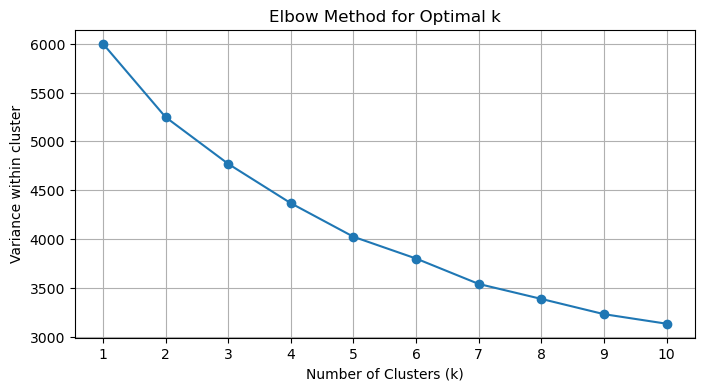

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Elbow method to find optimal k
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_marketing_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Variance within cluster')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [9]:
#running k means on clustered data

kmeans = KMeans(n_clusters=6, random_state=42)
df_marketing['segment'] = kmeans.fit_predict(df_marketing_scaled)

print(df_marketing['segment'].value_counts())

segment
5    177
0    174
3    170
4    165
1    164
2    150
Name: count, dtype: int64


In [10]:
#profiling the segments
segment_profile = df_marketing.groupby('segment')[features].mean().round(2)
print(segment_profile)

           age     income  spending_score  membership_years  \
segment                                                       
0        42.41   71998.33           27.99              3.90   
1        56.35  100017.90           30.34              5.15   
2        51.17  124051.95           66.58              5.59   
3        50.46   56257.02           69.32              7.05   
4        34.59   82619.40           72.33              3.95   
5        29.37  100375.52           40.30              7.11   

         purchase_frequency  last_purchase_amount  
segment                                            
0                     21.67                779.07  
1                     22.33                230.11  
2                     28.35                725.07  
3                     33.25                600.73  
4                     17.29                278.58  
5                     36.19                351.43  


In [11]:
#naming the segments based on results seen above
segment_names = {
    0: 'Infrequent Big Spenders',
    1: 'Older Inactive Shoppers',
    2: 'High Value Customers',
    3: 'Loyal Everyday Shoppers',
    4: 'Young Casual Shoppers',
    5: 'Young Active Shoppers'
}

df_marketing['segment_name'] = df_marketing['segment'].map(segment_names)

# Verify
print(df_marketing['segment_name'].value_counts())

segment_name
Young Active Shoppers      177
Infrequent Big Spenders    174
Loyal Everyday Shoppers    170
Young Casual Shoppers      165
Older Inactive Shoppers    164
High Value Customers       150
Name: count, dtype: int64


In [12]:
#visualizing segments
import matplotlib.pyplot as plt
import numpy as np

# Segment profile data
segment_profile = df_marketing.groupby('segment_name')[features].mean().round(2)

# Adding count of customers per segment
segment_profile['customer_count'] = df_marketing['segment_name'].value_counts()

#visualizing in a table
styled_profile = segment_profile.style \
    .background_gradient(cmap='YlOrRd', subset=['income', 'last_purchase_amount', 'spending_score']) \
    .background_gradient(cmap='YlGn', subset=['membership_years', 'purchase_frequency', 'age']) \
    .format({'income': '${:,.0f}', 
             'last_purchase_amount': '${:,.0f}',
             'spending_score': '{:.1f}',
             'membership_years': '{:.1f}',
             'purchase_frequency': '{:.1f}',
             'customer_count': '{:.0f}'}) \
    .set_caption('Customer Segment Profiles')

styled_profile
#the yellow to read colors indicate amount from low to high when it comes to income and spending
#the yellow to green colors indicate frequency/amount of time from low to high 

,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount,customer_count
segment_name,,,,,,,
High Value Customers,51.170000,"$124,052",66.6,5.6,28.4,$725,150
Infrequent Big Spenders,42.410000,"$71,998",28.0,3.9,21.7,$779,174
Loyal Everyday Shoppers,50.460000,"$56,257",69.3,7.0,33.2,$601,170
Older Inactive Shoppers,56.350000,"$100,018",30.3,5.2,22.3,$230,164
Young Active Shoppers,29.370000,"$100,376",40.3,7.1,36.2,$351,177
Young Casual Shoppers,34.590000,"$82,619",72.3,4.0,17.3,$279,165


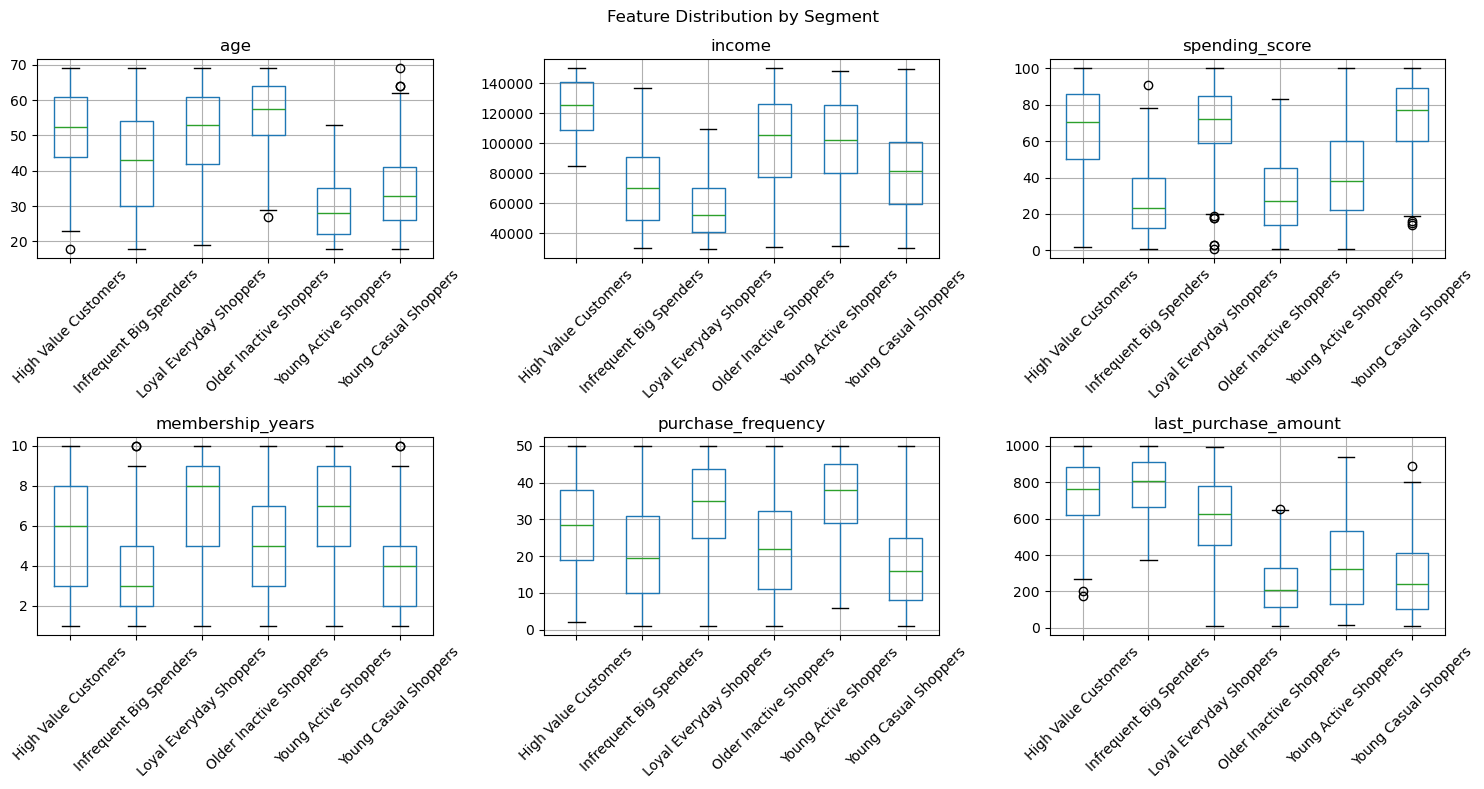

In [13]:
#creating boxplots for visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feature in zip(axes.flatten(), features):
    df_marketing.boxplot(column=feature, by='segment_name', ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Feature Distribution by Segment')
plt.tight_layout()
plt.show()

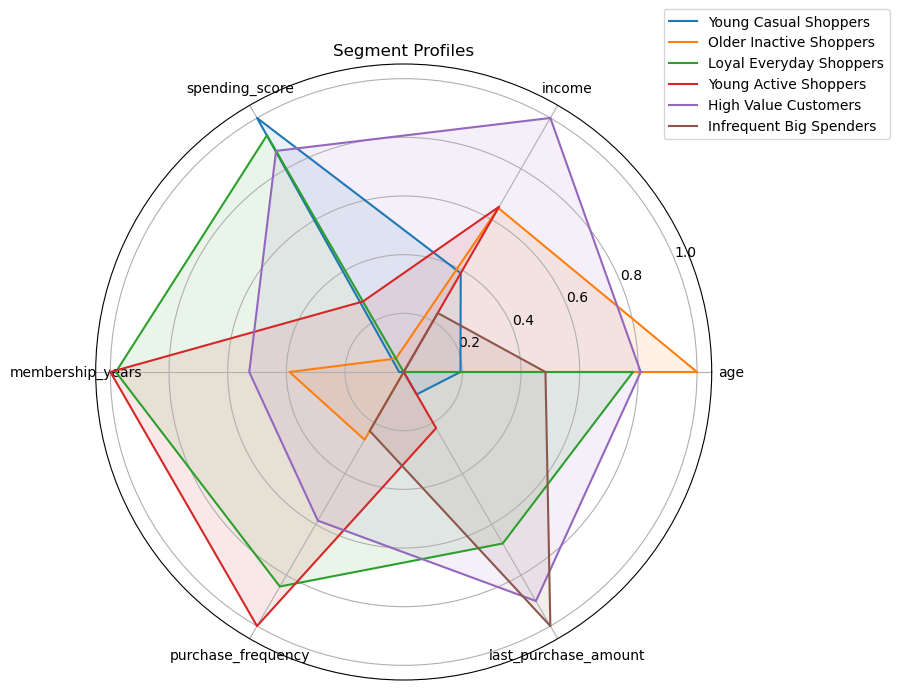

In [14]:
#creating a radar chart to compare segments
from matplotlib.patches import FancyArrowPatch
import numpy as np

categories = features
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for seg in df_marketing['segment_name'].unique():
    values = segment_profile.loc[seg, features].values.flatten().tolist()
    # normalize to 0-1 for comparison
    values = [(v - min(segment_profile[f])) / (max(segment_profile[f]) - min(segment_profile[f])) 
              for v, f in zip(values, features)]
    values += values[:1]
    ax.plot(angles, values, label=seg)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title('Segment Profiles')
plt.show()


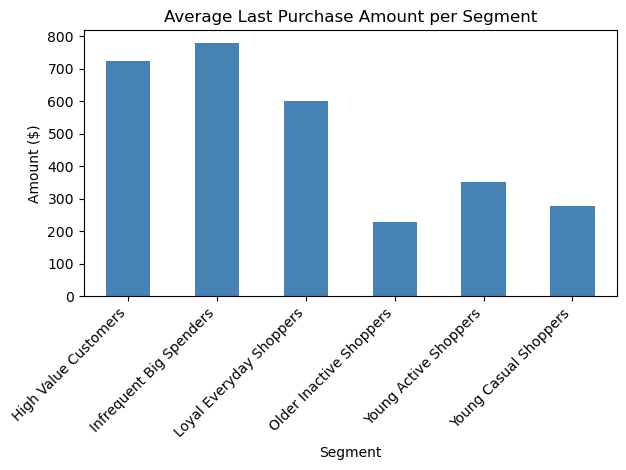

In [15]:
#Analysing sales per segment
#average last purchase amount per segment
df_marketing.groupby('segment_name')['last_purchase_amount'].mean().plot(kind='bar', color='steelblue')
plt.title('Average Last Purchase Amount per Segment')
plt.xlabel('Segment')
plt.ylabel('Amount ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

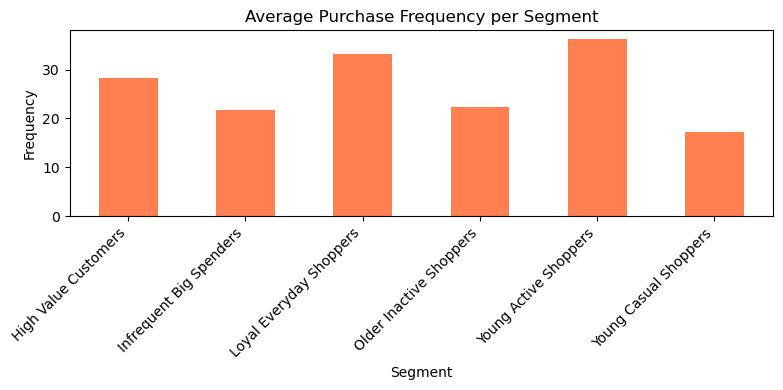

In [16]:
#purchase frequency per segment
plt.figure(figsize=(8, 4))
df_marketing.groupby('segment_name')['purchase_frequency'].mean().plot(kind='bar', color='coral')
plt.title('Average Purchase Frequency per Segment')
plt.xlabel('Segment')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

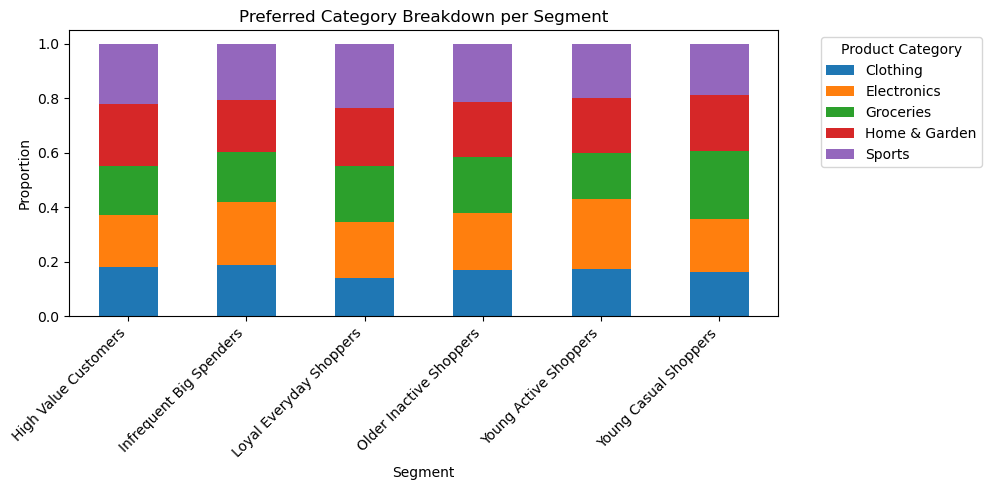

In [17]:
#preferred category per segment
plt.figure(figsize=(10, 5))
pd.crosstab(df_marketing['segment_name'], 
            df_marketing['preferred_category_original'], 
            normalize='index').plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title('Preferred Category Breakdown per Segment')
plt.xlabel('Segment')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 6 Using Gemini API
In this section I used Gemini API to create targeted marketing strategies for each identified customer segment from the previous section. The reviewers can skip the Gemini API step by just loading the final data from this in the next section (7 Exporting data).

In [146]:
!pip install anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.6/753.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [anthropic]━ 1/2 [anthropic]


In [21]:
#loading api key 
from google import genai
import os
from dotenv import load_dotenv

load_dotenv()

client = genai.Client(api_key=os.environ.get("GEMINI_API_KEY"))

# Test connection
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="Say hello!"
)
print(response.text)

Hello!


In [29]:
#segment profile function
def build_segment_summary(segment_name):
    seg_data = df_marketing[df_marketing['segment_name'] == segment_name]
    profile = seg_data[features].mean().round(2)
    top_category = seg_data['preferred_category_original'].mode()[0]
    
    summary = f"""
    Segment: {segment_name}
    - Average Age: {profile['age']:.0f} years
    - Average Income: ${profile['income']:,.0f}
    - Average Spending Score: {profile['spending_score']:.1f}/100
    - Average Membership Years: {profile['membership_years']:.1f}
    - Average Purchase Frequency: {profile['purchase_frequency']:.1f} per year
    - Average Last Purchase Amount: ${profile['last_purchase_amount']:,.0f}
    - Most Popular Category: {top_category}
    - Number of Customers: {len(seg_data)}
    """
    return summary

#printing out segments to test the function before using Gemini API

print(build_segment_summary('High Value Customers'))
print()
print(build_segment_summary('Infrequent Big Spenders'))
print()
print(build_segment_summary('Loyal Everyday Shoppers'))
print()
print(build_segment_summary('Older Inactive Shoppers'))
print()
print(build_segment_summary('Young Active Shoppers'))
print()
print(build_segment_summary('Young Casual Shoppers'))


    Segment: High Value Customers
    - Average Age: 51 years
    - Average Income: $124,052
    - Average Spending Score: 66.6/100
    - Average Membership Years: 5.6
    - Average Purchase Frequency: 28.4 per year
    - Average Last Purchase Amount: $725
    - Most Popular Category: Home & Garden
    - Number of Customers: 150
    


    Segment: Infrequent Big Spenders
    - Average Age: 42 years
    - Average Income: $71,998
    - Average Spending Score: 28.0/100
    - Average Membership Years: 3.9
    - Average Purchase Frequency: 21.7 per year
    - Average Last Purchase Amount: $779
    - Most Popular Category: Electronics
    - Number of Customers: 174
    


    Segment: Loyal Everyday Shoppers
    - Average Age: 50 years
    - Average Income: $56,257
    - Average Spending Score: 69.3/100
    - Average Membership Years: 7.0
    - Average Purchase Frequency: 33.2 per year
    - Average Last Purchase Amount: $601
    - Most Popular Category: Sports
    - Number of Customers: 1

In [26]:
def get_marketing_strategy(segment_name):
    summary = build_segment_summary(segment_name)
    
    prompt = f"""You are a marketing strategist. Based on this customer segment profile,
    provide a brief marketing strategy including:
    1. A one-sentence persona description
    2. Top 3 marketing recommendations
    3. Best channel to reach them
    
    Customer Segment Profile:
    {summary}
    
    Keep your response concise and actionable."""
    
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )
    return response.text

# Run for all segments
strategies = {}
for segment in df_marketing['segment_name'].unique():
    print(f"\n{'='*50}")
    print(f"Segment: {segment}")
    print('='*50)
    strategy = get_marketing_strategy(segment)
    strategies[segment] = strategy
    print(strategy)


Segment: Young Casual Shoppers
Here is a concise marketing strategy for "Young Casual Shoppers":

1.  **One-sentence persona description:** A loyal and busy 35-year-old, frequently stocking up on groceries, who appreciates value and convenience in their consistent shopping habits.

2.  **Top 3 marketing recommendations:**
    *   **Personalized Loyalty Offers:** Leverage their high frequency and long membership with targeted discounts on groceries, recipe inspirations, or exclusive early access to popular products.
    *   **Streamlined Digital Convenience:** Enhance online ordering, quick re-order features, and efficient delivery/pickup options to cater to their busy lifestyle and frequent grocery needs.
    *   **Value-Driven Bundles & Subscriptions:** Introduce recurring grocery bundles or "stock-up" deals that offer perceived value and simplify repeat purchases for their most popular category.

3.  **Best channel to reach them:** Email Marketing (for personalized offers and promot

# 7 Exporting results
In this section I am exporting the results of the project, first the full results and then smaller summaries that help reviewers view the results. Below is also a cell where reviewers can load these back into the jupyter notebook to inspect them.

In [38]:
#exporting full customer segment data with marketing strategies
df_marketing.to_csv('data/customers_analyzed.csv', index=False)
print(f"Exported {len(df_marketing)} customers to customers_analyzed.csv")

Exported 1000 customers to customers_analyzed.csv


In [35]:
#also exporting a customer segment summary which is easier for peer reviewers to look at
segment_summary = df_marketing.groupby('segment_name')[features].mean().round(2)
segment_summary['customer_count'] = df_marketing['segment_name'].value_counts()
segment_summary['top_category'] = df_marketing.groupby('segment_name')['preferred_category_original'].agg(lambda x: x.mode()[0])
segment_summary['marketing_strategy'] = pd.Series(strategies)

segment_summary.to_csv('data/segment_profiles.csv')
print(f"Exported {len(segment_summary)} segment profiles to segment_profiles.csv")
print()
display(segment_summary)

Exported 6 segment profiles to segment_profiles.csv



,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount,customer_count,top_category,marketing_strategy
segment_name,,,,,,,,,
High Value Customers,51.17,124051.95,66.58,5.59,28.35,725.07,150,Home & Garden,Here's a brief marketing strategy for your Hig...
Infrequent Big Spenders,42.41,71998.33,27.99,3.90,21.67,779.07,174,Electronics,"Here's a brief marketing strategy for the ""Inf..."
Loyal Everyday Shoppers,50.46,56257.02,69.32,7.05,33.25,600.73,170,Sports,"Here's a brief marketing strategy for your ""Lo..."
Older Inactive Shoppers,56.35,100017.90,30.34,5.15,22.33,230.11,164,Sports,"Here's a brief marketing strategy for the ""Old..."
Young Active Shoppers,29.37,100375.52,40.30,7.11,36.19,351.43,177,Electronics,"Here's a brief marketing strategy for ""Young A..."
Young Casual Shoppers,34.59,82619.40,72.33,3.95,17.29,278.58,165,Groceries,"Here is a concise marketing strategy for ""Youn..."


In [37]:
#exporting segment sales analysis to a separate file
sales_summary = df_marketing.groupby('segment_name').agg(
    customer_count=('id', 'count'),
    avg_income=('income', 'mean'),
    avg_spending_score=('spending_score', 'mean'),
    avg_purchase_frequency=('purchase_frequency', 'mean'),
    avg_last_purchase=('last_purchase_amount', 'mean'),
    total_purchase_value=('last_purchase_amount', 'sum')
).round(2)

sales_summary.to_csv('data/sales_by_segment.csv')
print(f"Exported sales analysis to sales_by_segment.csv")
print()
display(sales_summary) #for visualisation

Exported sales analysis to sales_by_segment.csv



,customer_count,avg_income,avg_spending_score,avg_purchase_frequency,avg_last_purchase,total_purchase_value
segment_name,,,,,,
High Value Customers,150,124051.95,66.58,28.35,725.07,108760.13
Infrequent Big Spenders,174,71998.33,27.99,21.67,779.07,135558.58
Loyal Everyday Shoppers,170,56257.02,69.32,33.25,600.73,102123.39
Older Inactive Shoppers,164,100017.90,30.34,22.33,230.11,37737.83
Young Active Shoppers,177,100375.52,40.30,36.19,351.43,62203.02
Young Casual Shoppers,165,82619.40,72.33,17.29,278.58,45965.72


In [ ]:
#For peer reviewers:
#Load data for reviewing:

# df_marketing = pd.read_csv('customers_analyzed.csv')
# segment_summary = pd.read_csv('segment_profiles.csv', index_col=0)
# sales_summary = pd.read_csv('sales_by_segment.csv', index_col=0)

# 8 Conclusion and findings
In this project I have analyzed a dataset containing customer segment data. First, I identified 6 different customer segments, based on age, income, spending, membership years, last purchase amount and purchase frequency. The identified customer segments different from each other especially in income, age, and spending score. The difference between the customer segments is visualized in the radar chart in the data analysis section. Below I have also displayed the 6 identified segments and their names.

After I identified the segments, I conducted analysis on the sales for each segment, which were also visualized in various figures in the data analysis section. Spending frequency and last purchase amount had significant variation between customer segments. High value customers had the highest average purchase amounts, while the Older Inactive Shoppers have a high income level but lowest purchasing, making them an untapped opportunity. Young Active Shoppers had high purchasing frequency but lower spending, also suggesting a potential for more sales for this segment. However, I found that preferred category was quite similar for each customer segment, but this is understandable as I used a simulated dataset from Kaggle rather than real customer data, which explains this. It is unfortunate but expected. Some very small variation could still be found, which were used for the personalized marketing recommendations.

Based on the previous analysis, I used Gemini API to create targeted marketing strategies for each customer segment. This included special promotions and membership loyalty programs, as well as targeted campaigns for specific customer segments. Gemini also created a buyer persona summary describing the buyer personas in each customer segment. It also chose the best channel to reach each customer segment based on the previous analysis. These results were showcased in the Gemini API section. Below I have also included a summary over the recommended marketing channels for each customer segment. 

There are some limitations for this project that should be considered. The dataset I used is simulated meaning that the results here don't reflect real-world customer segments. However, this project shows how similar programming can be used in real-world situations to find customer segments and personalize marketing strategies based on the findings. The K-means clusering used in this project also assumes spherical clusters that have similar sizes, which might not reflect natural groupings. This means the results might be slightly skewed.

All in all this project shows how customer data can be analyzed using different methods to find customer segments and conduct specific sales analysis on the identified segments. This in turn can then be used to create targeted marketing strategies for different customer segments.

In [30]:
#saving marketing strategies to a dataframe
df_marketing['marketing_strategy'] = df_marketing['segment_name'].map(strategies)

#visualizing dataframe
df_marketing[['segment_name', 'marketing_strategy']].drop_duplicates()

,segment_name,marketing_strategy
0,Young Casual Shoppers,"Here is a concise marketing strategy for ""Youn..."
2,Older Inactive Shoppers,"Here's a brief marketing strategy for the ""Old..."
3,Loyal Everyday Shoppers,"Here's a brief marketing strategy for your ""Lo..."
6,Young Active Shoppers,"Here's a brief marketing strategy for ""Young A..."
7,High Value Customers,Here's a brief marketing strategy for your Hig...
8,Infrequent Big Spenders,"Here's a brief marketing strategy for the ""Inf..."


In [40]:
#showcasing the best channels to reach each segment according to Gemini API
def extract_best_channel(text):
    lines = text.split('\n')
    for line in lines:
        if 'channel' in line.lower():
            return line.strip()
    return 'Not found'

print("\nBest channel per segment:")
print("-" * 50)
for segment, strategy in strategies.items():
    channel = extract_best_channel(strategy)
    print(f"{segment}")
    print(f"  → {channel}\n")


Best channel per segment:
--------------------------------------------------
Young Casual Shoppers
  → 3.  **Best channel to reach them:** Email Marketing (for personalized offers and promotions) combined with In-App Notifications (for convenience and real-time deals).

Older Inactive Shoppers
  → 3.  **Best channel to reach them:** Personalized Email Campaigns

Loyal Everyday Shoppers
  → 3.  **Best Channel to Reach Them:** Personalized Email Marketing

Young Active Shoppers
  → 3.  **Best channel to reach them:** **Social Media (YouTube, Instagram, TikTok)**, complemented by highly targeted digital advertising on tech-focused platforms.

High Value Customers
  → 3.  **Best channel to reach them:** Personalized Email Marketing

Infrequent Big Spenders
  → 3.  **Best channel to reach them:**

